# PyTorch BiLSTM classifier (E1)

The vocabulary is built from training text only. The official test set is used only for final evaluation.

## Course connection

This notebook applies the ideas from `references/course/5_Embeddings.ipynb` and `references/course/6_LSTM.ipynb`: integer token IDs are mapped through `nn.Embedding`, then processed by a bidirectional LSTM before classification.

## Step 1 — Prepare the BiLSTM experiment

**What this does:** fixes the random seed, selects the device, loads BANKING77, and builds a training-only vocabulary.

**Why:** building the vocabulary from training text prevents information from the validation or test data leaking into the model.


In [1]:
# Set the seed before creating data loaders or model weights so the run can be reproduced.
# The vocabulary is learned from training queries only; unseen words use <UNK>.
# Keep the experiment reproducible and build the vocabulary from training text only.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import copy, time
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score
from src.data.load_data import load_banking77
from src.models.bilstm import build_vocab, collate_batch, BiLSTMClassifier
from src.utils import set_seed, get_device
set_seed(42)
device = get_device()
dataset = load_banking77(validation_size=0.1, seed=42)
train, validation, test = dataset["train"], dataset["validation"], dataset["test"]
vocab = build_vocab(train["text"])
print({"device": str(device), "vocab_size": len(vocab), "train": len(train), "validation": len(validation), "test": len(test)})

{'device': 'cuda', 'vocab_size': 3966, 'train': 9002, 'validation': 1001, 'test': 3080}


## Step 2 — Train with validation-based early stopping

**What this does:** pads batches, trains the BiLSTM, measures validation Macro-F1, and keeps the best checkpoint.

**Why:** Macro-F1 gives all 77 intents equal importance, and early stopping prevents us from keeping a later overfitted model.


In [2]:
# The explicit loop makes the course concepts visible: forward pass, loss, backward pass, and optimizer update.
# Validation is never used to update weights; it only decides whether the current checkpoint is best.
# The training loop is written explicitly so each learning step remains visible.
from pathlib import Path

def make_loader(split, shuffle):
    # Each example is kept as (raw text, integer label) until batching.
    pairs = list(zip(split["text"], split["label"]))
    return DataLoader(
        pairs,
        batch_size=64,
        shuffle=shuffle,
        collate_fn=lambda batch: collate_batch(batch, vocab),
    )

train_loader = make_loader(train, shuffle=True)
validation_loader = make_loader(validation, shuffle=False)
model = BiLSTMClassifier(len(vocab), num_classes=77).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, training):
    # Training mode enables dropout and gradient updates; validation mode does not.
    model.train(training)
    total_loss = 0.0
    y_true, y_pred = [], []

    for inputs, lengths, labels in loader:
        inputs = inputs.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(inputs, lengths)
        loss = criterion(logits, labels)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(labels)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(1).cpu().tolist())

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
    )

# Stop when validation Macro-F1 has not improved for three consecutive epochs.
max_epochs = 10
early_stop_patience = 3
epochs_without_improvement = 0
best_state = None
best_f1 = -1.0
history = []
start = time.perf_counter()

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc, train_f1 = run_epoch(train_loader, training=True)
    val_loss, val_acc, val_f1 = run_epoch(validation_loader, training=False)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "validation_accuracy": val_acc,
        "validation_macro_f1": val_f1,
    }
    history.append(row)
    print(row)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping after epoch {epoch}.")
            break

print("training_seconds", time.perf_counter() - start)
model.load_state_dict(best_state)

# Save artifacts in the repository-level results directory, not beside the notebook.
results_dir = Path.cwd().parent / "results"
(results_dir / "logs").mkdir(parents=True, exist_ok=True)
(results_dir / "logs" / "bilstm_history.json").write_text(
    __import__("json").dumps(history, indent=2)
)
torch.save(model.state_dict(), results_dir / "bilstm_best.pt")

{'epoch': 1, 'train_loss': 3.6258640530320756, 'validation_loss': 2.3652635656751237, 'validation_accuracy': 0.47352647352647353, 'validation_macro_f1': 0.42854468857103417}


{'epoch': 2, 'train_loss': 1.719362621120918, 'validation_loss': 1.389584948252012, 'validation_accuracy': 0.6443556443556444, 'validation_macro_f1': 0.6200543944335273}


{'epoch': 3, 'train_loss': 1.0286545162597145, 'validation_loss': 1.0504881305532618, 'validation_accuracy': 0.7292707292707292, 'validation_macro_f1': 0.7184227718064055}


{'epoch': 4, 'train_loss': 0.7087450701510792, 'validation_loss': 0.8948217561314037, 'validation_accuracy': 0.7512487512487512, 'validation_macro_f1': 0.7397526225809319}


{'epoch': 5, 'train_loss': 0.5035905009427354, 'validation_loss': 0.8271562974531572, 'validation_accuracy': 0.7672327672327672, 'validation_macro_f1': 0.761346218832275}


{'epoch': 6, 'train_loss': 0.362634107275185, 'validation_loss': 0.7633147096776819, 'validation_accuracy': 0.7772227772227772, 'validation_macro_f1': 0.770512662732119}


{'epoch': 7, 'train_loss': 0.2608741044574408, 'validation_loss': 0.7319842016065752, 'validation_accuracy': 0.7902097902097902, 'validation_macro_f1': 0.7839262047817935}


{'epoch': 8, 'train_loss': 0.19588568228611652, 'validation_loss': 0.6974735542253538, 'validation_accuracy': 0.7922077922077922, 'validation_macro_f1': 0.7829997718819098}


{'epoch': 9, 'train_loss': 0.1431635426838672, 'validation_loss': 0.6859770026002135, 'validation_accuracy': 0.7982017982017982, 'validation_macro_f1': 0.7875099437806735}


{'epoch': 10, 'train_loss': 0.11269885094675375, 'validation_loss': 0.6716835043885253, 'validation_accuracy': 0.8011988011988012, 'validation_macro_f1': 0.7958679880300001}
training_seconds 9.506706842003041


## Training curves — E1 BiLSTM

**What this does:** displays the saved training/validation loss and validation Macro-F1.

**Why:** curves show whether learning is progressing, whether the model is overfitting, and how the best checkpoint was selected.

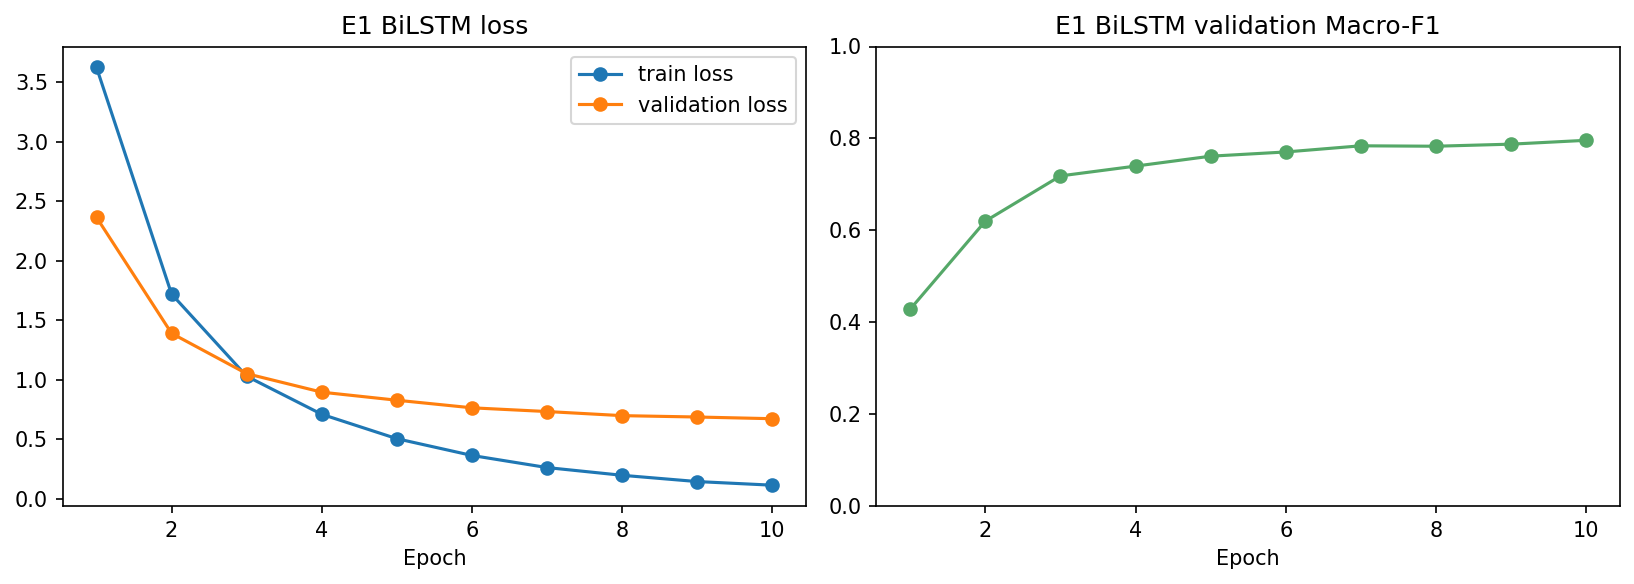

In [ ]:
# Read the saved history produced by the training step.
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
history_file = root / "results/logs/bilstm_history.json"
history_data = json.loads(history_file.read_text())
history = history_data if isinstance(history_data, list) else history_data["history"]
frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(frame["epoch"], frame["train_loss"], marker="o", label="train loss")
axes[0].plot(frame["epoch"], frame["validation_loss"], marker="o", label="validation loss")
axes[0].set_title("E1 BiLSTM loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(frame["epoch"], frame["validation_macro_f1"], marker="o", color="#55A868")
axes[1].set_title("E1 BiLSTM validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()